# Model 1 — Baseline CNN

**Group**: Group 14  
**Members**: P1, P2, P3, P4, P5 *(update with real names)*  
**Model owner**: P1  
**Architecture**: Simple Conv2D stack (3 blocks)  
**Dataset**: NIH Malaria Cell Images — Parasitized vs Uninfected  
**Date**: June 2026

---
This notebook establishes the performance baseline for the group.  
All 5 members must run this notebook and confirm matching train/val/test sizes before forking for individual models.

## 1. Environment Setup
Set all random seeds for reproducibility and verify GPU availability.

In [1]:
import os, sys, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus if gpus else 'None — training on CPU')

TensorFlow version: 2.21.0
GPU available: None — training on CPU


## 2. Dataset Download
Download the NIH Malaria dataset via `kagglehub`. The path is resolved dynamically so this notebook runs on any machine.

In [2]:
import kagglehub

path = kagglehub.dataset_download('iarunava/cell-images-for-detecting-malaria')
print('Downloaded to:', path)

# Find the subfolder that contains Parasitized/ and Uninfected/
DATA_DIR = None
for root, dirs, _ in os.walk(path):
    if 'Parasitized' in dirs and 'Uninfected' in dirs:
        DATA_DIR = root
        break

assert DATA_DIR is not None, 'Could not locate Parasitized/Uninfected folders'
print('DATA_DIR:', DATA_DIR)
print('Parasitized images:', len(os.listdir(os.path.join(DATA_DIR, 'Parasitized'))))
print('Uninfected images: ', len(os.listdir(os.path.join(DATA_DIR, 'Uninfected'))))

c:\Users\Luqma\dev\projects\coursework\Group14_Formative2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: C:\Users\Luqma\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1
DATA_DIR: C:\Users\Luqma\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1\cell_images
Parasitized images: 13780
Uninfected images:  13780


## 3. Shared Utilities
Import all shared functions from `utils.py` in the project root.

In [5]:
# Add project root to path so utils.py is importable from notebooks/ subfolder
sys.path.insert(0, os.path.abspath('..'))

from utils import (
    load_dataset, evaluate_model,
    plot_learning_curves, plot_confusion_matrix, plot_roc_curve,
    build_results_table, get_callbacks, error_analysis,
    data_augmentation, CLASS_NAMES,
)

## 4. Load Dataset
Baseline CNN uses 64×64 images (smaller than pretrained models) to reduce memory and training time.  
All members must confirm the same split sizes: **Train: ~22046 | Val: ~2756 | Test: ~2756**.

In [6]:
BATCH_SIZE = 32
IMAGE_SIZE = (64, 64)  # Baseline uses 64x64; pretrained models use 224x224

train_ds, val_ds, test_ds = load_dataset(
    data_dir=DATA_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

n_train = sum(1 for _ in train_ds) * BATCH_SIZE
n_val   = sum(1 for _ in val_ds)   * BATCH_SIZE
n_test  = sum(1 for _ in test_ds)  * BATCH_SIZE
print(f'Train: ~{n_train} | Val: ~{n_val} | Test: ~{n_test}')

Found 27558 files belonging to 2 classes.
Train: ~22048 | Val: ~2784 | Test: ~2784


## 5. Model Architecture
Baseline CNN: three Conv2D blocks (32→64→128 filters) with BatchNorm and MaxPooling, followed by a Dense classification head.  
This architecture is intentionally simple to serve as a lower-bound benchmark.

In [7]:
def build_baseline_cnn(input_shape=(64, 64, 3), dropout_rate=0.5, filters=(32, 64, 128)):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        # Block 1
        tf.keras.layers.Conv2D(filters[0], (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Block 2
        tf.keras.layers.Conv2D(filters[1], (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Block 3
        tf.keras.layers.Conv2D(filters[2], (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Classification head
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ], name='baseline_cnn')
    return model

# Preview the default architecture
build_baseline_cnn().summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,977 (4.36 MB)

 Trainable params: 1,142,529 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 6. Experiment Tracking
All experiment results are logged here. The table is displayed after all 7 runs.

In [9]:
results_log = []  # Append one dict per experiment — never overwrite

---
## Experiment 1: Baseline Configuration

**Hypothesis**: A minimal 3-block CNN with standard hyperparameters (LR=1e-3, dropout=0.5, 20 epochs) should achieve a reasonable baseline accuracy around 88–92%, establishing the lower bound for comparison.

**Change made**: No change — this is the starting configuration.

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.6643 - loss: 0.8936

689/689 ━━━━━━━━━━━━━━━━━━━━ 309s 438ms/step - accuracy: 0.7864 - loss: 0.4923 - val_accuracy: 0.9408 - val_loss: 0.1766 - learning_rate: 0.0010
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.9366 - loss: 0.2002

689/689 ━━━━━━━━━━━━━━━━━━━━ 248s 359ms/step - accuracy: 0.9379 - loss: 0.1995 - val_accuracy: 0.9441 - val_loss: 0.1482 - learning_rate: 0.0010
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 192s 278ms/step - accuracy: 0.9455 - loss: 0.1704 - val_accuracy: 0.9437 - val_loss: 0.1578 - learning_rate: 0.0010
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.9490 - loss: 0.1572

689/689 ━━━━━━━━━━━━━━━━━━━━ 170s 247ms/step - accuracy: 0.9509 - loss: 0.1559 - val_accuracy: 0.9593 - val_loss: 0.1226 - learning_rate: 0.0010
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 165s 240ms/step - accuracy: 0.9548 - loss: 0.1444 - val_accuracy: 0.9466 - val_loss: 0.1439 - learning_rate: 0.0010
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 197s 286ms/step - accuracy: 0.9539 - loss: 0.1433 - val_accuracy: 0.9474 - val_loss: 0.1563 - learning_rate: 0.0010
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 201s 292ms/step - accuracy: 0.9564 - loss: 0.1328 - val_accuracy: 0.9474 - val_loss: 0.1452 - learning_rate: 0.0010
Epoch 8/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 190s 276ms/step - accuracy: 0.9588 - loss: 0.1175 - val_accuracy: 0.9543 - val_loss: 0.1432 - learning_rate: 0.0010
Epoch 9/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9600 - loss: 0.1178
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


689/689 ━━━━━━━━━━━━━━━━━━━━ 225s 327ms/step - accuracy: 0.9591 - loss: 0.1182 - val_accuracy: 0.9597 - val_loss: 0.1236 - learning_rate: 0.0010
Epoch 10/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 1408s 2s/step - accuracy: 0.9660 - loss: 0.0965 - val_accuracy: 0.9561 - val_loss: 0.1357 - learning_rate: 5.0000e-04
Epoch 11/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 620s 901ms/step - accuracy: 0.9702 - loss: 0.0822 - val_accuracy: 0.9597 - val_loss: 0.1550 - learning_rate: 5.0000e-04
Epoch 12/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9700 - loss: 0.0795

689/689 ━━━━━━━━━━━━━━━━━━━━ 145s 211ms/step - accuracy: 0.9721 - loss: 0.0752 - val_accuracy: 0.9655 - val_loss: 0.1395 - learning_rate: 5.0000e-04
Epoch 13/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9738 - loss: 0.0702

689/689 ━━━━━━━━━━━━━━━━━━━━ 195s 283ms/step - accuracy: 0.9749 - loss: 0.0681 - val_accuracy: 0.9662 - val_loss: 0.1318 - learning_rate: 5.0000e-04
Epoch 14/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9778 - loss: 0.0602
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
689/689 ━━━━━━━━━━━━━━━━━━━━ 219s 319ms/step - accuracy: 0.9786 - loss: 0.0583 - val_accuracy: 0.9615 - val_loss: 0.1910 - learning_rate: 5.0000e-04
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 4.

Exp 1 — Baseline config: LR=1e-3, dropout=0.5, 20 epochs
Accuracy:  0.9554
Precision: 0.9313
Recall:    0.9842
F1-Score:  0.957
AUC:       0.9923


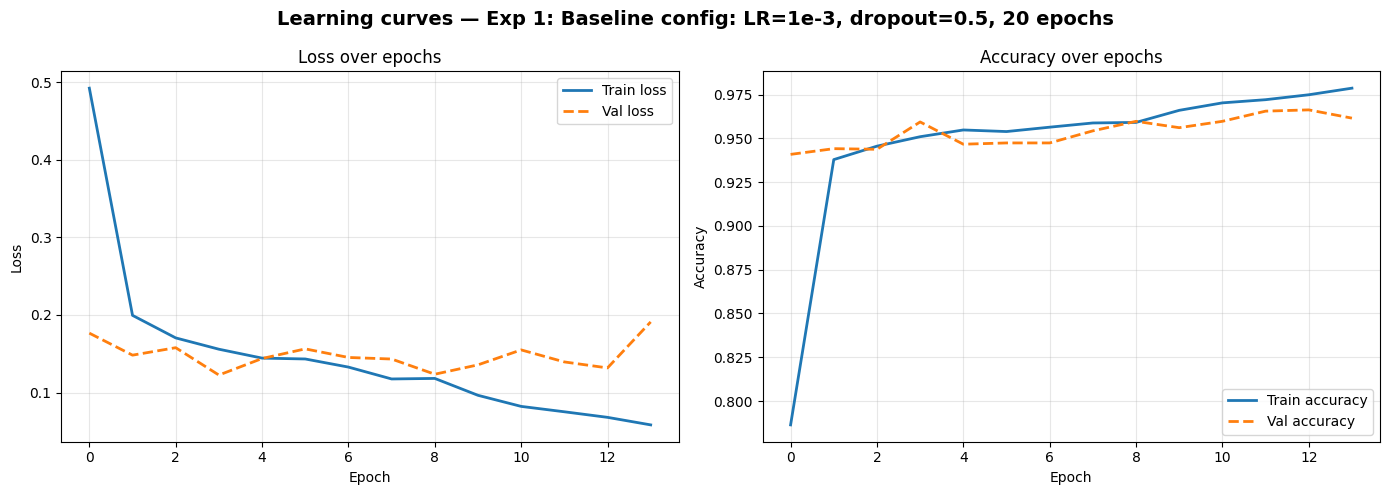

✅ Good fit: train 0.979 vs val 0.962 (gap=0.017)


In [10]:
EXP_NUM         = 1
EXP_DESCRIPTION = 'Baseline config: LR=1e-3, dropout=0.5, 20 epochs'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.5

model1 = build_baseline_cnn(dropout_rate=DROPOUT)
model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics1 = evaluate_model(model1, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics1["accuracy"]}')
print(f'Precision: {metrics1["precision"]}')
print(f'Recall:    {metrics1["recall"]}')
print(f'F1-Score:  {metrics1["f1"]}')
print(f'AUC:       {metrics1["auc"]}')

plot_learning_curves(
    history1,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'../figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics1['accuracy'],
    'precision':   metrics1['precision'],
    'recall':      metrics1['recall'],
    'f1':          metrics1['f1'],
    'auc':         metrics1['auc'],
    'epochs':      len(history1.history['loss']),
    'notes':       'Early stop ep14, best ep4; overfit signal in val_loss; Recall=0.9842 clinically strong'
})

**Interpretation**: Early stopping halted training at epoch 14, restoring best weights from epoch 4, indicating the model reached peak validation performance quickly and then overfit. The validation loss curve shows its minimum (~0.12) at epoch 4 before rising to ~0.19 by epoch 14, while training loss continued falling to ~0.06 — a clear overfitting signal despite the modest accuracy gap (train 0.979 vs val 0.962, gap=0.017). The model achieved strong test metrics for a baseline: Accuracy=0.9554, F1=0.9570, AUC=0.9923. Clinically, Recall=0.9842 is the most important result — the model correctly identified 98.4% of parasitised cells, leaving very few infected patients undetected (low false-negative rate). Precision=0.9313 is lower than recall, meaning the model errs on the side of over-predicting infection, which is the safer clinical bias. The ReduceLROnPlateau callback halved the learning rate at epoch 14 (1e-3 → 2.5e-4) but could not recover generalisation, confirming overfitting had already set in. Experiments 2–7 should address this by trying a lower initial LR, higher dropout, and L2 regularisation to push the best validation epoch later into training.

---
## Experiment 2: Lower Learning Rate (LR = 1e-4)

**Hypothesis**: Reducing the learning rate from 1e-3 to 1e-4 should produce smoother convergence and may reduce oscillation in the validation loss, potentially improving generalisation at the cost of slower training.

**Change made**: `LEARNING_RATE = 1e-4`

In [ ]:
EXP_NUM         = 2
EXP_DESCRIPTION = 'Lower LR: 1e-4'
LEARNING_RATE   = 1e-4
EPOCHS          = 20
DROPOUT         = 0.5

model2 = build_baseline_cnn(dropout_rate=DROPOUT)
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics2 = evaluate_model(model2, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics2["accuracy"]}')
print(f'Precision: {metrics2["precision"]}')
print(f'Recall:    {metrics2["recall"]}')
print(f'F1-Score:  {metrics2["f1"]}')
print(f'AUC:       {metrics2["auc"]}')

plot_learning_curves(
    history2,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'../figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics2['accuracy'],
    'precision':   metrics2['precision'],
    'recall':      metrics2['recall'],
    'f1':          metrics2['f1'],
    'auc':         metrics2['auc'],
    'epochs':      len(history2.history['loss']),
    'notes':       '',
})

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.6798 - loss: 0.6515

689/689 ━━━━━━━━━━━━━━━━━━━━ 180s 256ms/step - accuracy: 0.7540 - loss: 0.5020 - val_accuracy: 0.8163 - val_loss: 0.4003 - learning_rate: 1.0000e-04
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9005 - loss: 0.2470

689/689 ━━━━━━━━━━━━━━━━━━━━ 159s 231ms/step - accuracy: 0.9158 - loss: 0.2192 - val_accuracy: 0.9368 - val_loss: 0.1692 - learning_rate: 1.0000e-04
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9411 - loss: 0.1727

689/689 ━━━━━━━━━━━━━━━━━━━━ 149s 216ms/step - accuracy: 0.9421 - loss: 0.1672 - val_accuracy: 0.9459 - val_loss: 0.1480 - learning_rate: 1.0000e-04
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9502 - loss: 0.1424

689/689 ━━━━━━━━━━━━━━━━━━━━ 188s 273ms/step - accuracy: 0.9510 - loss: 0.1412 - val_accuracy: 0.9593 - val_loss: 0.1158 - learning_rate: 1.0000e-04
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 216s 314ms/step - accuracy: 0.9560 - loss: 0.1283 - val_accuracy: 0.9590 - val_loss: 0.1234 - learning_rate: 1.0000e-04
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 219s 318ms/step - accuracy: 0.9583 - loss: 0.1168 - val_accuracy: 0.9564 - val_loss: 0.1210 - learning_rate: 1.0000e-04
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9625 - loss: 0.1073

689/689 ━━━━━━━━━━━━━━━━━━━━ 233s 338ms/step - accuracy: 0.9627 - loss: 0.1042 - val_accuracy: 0.9615 - val_loss: 0.1185 - learning_rate: 1.0000e-04
Epoch 8/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 330s 478ms/step - accuracy: 0.9668 - loss: 0.0937 - val_accuracy: 0.9612 - val_loss: 0.1102 - learning_rate: 1.0000e-04
Epoch 9/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 327s 474ms/step - accuracy: 0.9702 - loss: 0.0816 - val_accuracy: 0.9546 - val_loss: 0.1462 - learning_rate: 1.0000e-04
Epoch 10/20
497/689 ━━━━━━━━━━━━━━━━━━━━ 2:38 828ms/step - accuracy: 0.9734 - loss: 0.0740

**Interpretation**: *(Compare convergence speed and validation stability against Exp 1. Did the lower LR improve or hurt performance?)*

---
## Experiment 3: Higher Dropout (dropout = 0.6)

**Hypothesis**: Increasing dropout from 0.5 to 0.6 introduces stronger regularisation, which should reduce overfitting if a train–val gap was observed in Exp 1. However, too much dropout may cause underfitting.

**Change made**: `DROPOUT = 0.6`

In [ ]:
EXP_NUM         = 3
EXP_DESCRIPTION = 'Higher dropout: 0.6'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.6

model3 = build_baseline_cnn(dropout_rate=DROPOUT)
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics3 = evaluate_model(model3, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics3["accuracy"]}')
print(f'Precision: {metrics3["precision"]}')
print(f'Recall:    {metrics3["recall"]}')
print(f'F1-Score:  {metrics3["f1"]}')
print(f'AUC:       {metrics3["auc"]}')

plot_learning_curves(
    history3,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'../figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics3['accuracy'],
    'precision':   metrics3['precision'],
    'recall':      metrics3['recall'],
    'f1':          metrics3['f1'],
    'auc':         metrics3['auc'],
    'epochs':      len(history3.history['loss']),
    'notes':       '',
})

**Interpretation**: *(Did increased dropout narrow the train–val gap? Did it hurt accuracy?)*

---
## Experiment 4: More Filters (64/128/256)

**Hypothesis**: Doubling the filter counts at each block increases model capacity, allowing the network to learn more complex feature representations. This should improve accuracy but risks overfitting if regularisation is insufficient.

**Change made**: `filters = (64, 128, 256)` instead of `(32, 64, 128)`

In [ ]:
EXP_NUM         = 4
EXP_DESCRIPTION = 'More filters: 64/128/256'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.5
FILTERS         = (64, 128, 256)

model4 = build_baseline_cnn(dropout_rate=DROPOUT, filters=FILTERS)
model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history4 = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics4 = evaluate_model(model4, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics4["accuracy"]}')
print(f'Precision: {metrics4["precision"]}')
print(f'Recall:    {metrics4["recall"]}')
print(f'F1-Score:  {metrics4["f1"]}')
print(f'AUC:       {metrics4["auc"]}')

plot_learning_curves(
    history4,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'../figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics4['accuracy'],
    'precision':   metrics4['precision'],
    'recall':      metrics4['recall'],
    'f1':          metrics4['f1'],
    'auc':         metrics4['auc'],
    'epochs':      len(history4.history['loss']),
    'notes':       '',
})

**Interpretation**: *(Did increased capacity improve F1? Was overfitting introduced?)*

---
## Experiment 5: L2 Regularisation

**Hypothesis**: Adding L2 weight decay (λ=1e-4) to the Conv2D layers penalises large weights, which should reduce overfitting by encouraging simpler learned filters compared to dropout alone.

**Change made**: `kernel_regularizer=l2(1e-4)` added to all Conv2D layers

In [ ]:
from tensorflow.keras.regularizers import l2

EXP_NUM         = 5
EXP_DESCRIPTION = 'L2 regularisation: λ=1e-4'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.5
L2_LAMBDA       = 1e-4

def build_baseline_cnn_l2(input_shape=(64, 64, 3), dropout_rate=0.5, l2_lambda=1e-4):
    reg = l2(l2_lambda)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32,  (3,3), activation='relu', padding='same', kernel_regularizer=reg),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(64,  (3,3), activation='relu', padding='same', kernel_regularizer=reg),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=reg),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ], name='baseline_cnn_l2')
    return model

model5 = build_baseline_cnn_l2(dropout_rate=DROPOUT, l2_lambda=L2_LAMBDA)
model5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history5 = model5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics5 = evaluate_model(model5, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics5["accuracy"]}')
print(f'Precision: {metrics5["precision"]}')
print(f'Recall:    {metrics5["recall"]}')
print(f'F1-Score:  {metrics5["f1"]}')
print(f'AUC:       {metrics5["auc"]}')

plot_learning_curves(
    history5,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'../figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics5['accuracy'],
    'precision':   metrics5['precision'],
    'recall':      metrics5['recall'],
    'f1':          metrics5['f1'],
    'auc':         metrics5['auc'],
    'epochs':      len(history5.history['loss']),
    'notes':       '',
})

**Interpretation**: *(Did L2 reduce the train–val gap compared to Exp 1? How does it compare to dropout alone?)*

---
## Experiment 6: Larger Batch Size (batch_size = 64)

**Hypothesis**: Doubling the batch size from 32 to 64 provides a more stable gradient estimate per step, which may speed up convergence and reduce training noise. However, it may generalise slightly worse than smaller batches due to sharper minima.

**Change made**: `BATCH_SIZE = 64` — reload the dataset with the new batch size

In [ ]:
EXP_NUM         = 6
EXP_DESCRIPTION = 'Larger batch size: 64'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.5
BATCH_SIZE_64   = 64

# Reload dataset with larger batch size
train_ds_64, val_ds_64, test_ds_64 = load_dataset(
    data_dir=DATA_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE_64,
)

model6 = build_baseline_cnn(dropout_rate=DROPOUT)
model6.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history6 = model6.fit(
    train_ds_64,
    validation_data=val_ds_64,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics6 = evaluate_model(model6, test_ds_64)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics6["accuracy"]}')
print(f'Precision: {metrics6["precision"]}')
print(f'Recall:    {metrics6["recall"]}')
print(f'F1-Score:  {metrics6["f1"]}')
print(f'AUC:       {metrics6["auc"]}')

plot_learning_curves(
    history6,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'../figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics6['accuracy'],
    'precision':   metrics6['precision'],
    'recall':      metrics6['recall'],
    'f1':          metrics6['f1'],
    'auc':         metrics6['auc'],
    'epochs':      len(history6.history['loss']),
    'notes':       '',
})

**Interpretation**: *(Did training converge faster? Any change in final accuracy or generalisation gap?)*

---
## Experiment 7: Early Stopping (patience = 5)

**Hypothesis**: Early stopping with patience=5 prevents the model from training past the point of best validation performance, acting as an automatic regulariser. This should reduce overfitting and select the best-generalising epoch rather than the last epoch.

**Change made**: Callbacks use `patience_es=5` (early stopping patience); allowed to train up to 50 epochs

In [ ]:
EXP_NUM         = 7
EXP_DESCRIPTION = 'Early stopping: patience=5, max 50 epochs'
LEARNING_RATE   = 1e-3
EPOCHS          = 50  # Let early stopping decide when to halt
DROPOUT         = 0.5

model7 = build_baseline_cnn(dropout_rate=DROPOUT)
model7.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history7 = model7.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM, patience_es=5, patience_lr=3),
    verbose=1,
)

metrics7 = evaluate_model(model7, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Stopped at epoch: {len(history7.history["loss"])}')
print(f'Accuracy:  {metrics7["accuracy"]}')
print(f'Precision: {metrics7["precision"]}')
print(f'Recall:    {metrics7["recall"]}')
print(f'F1-Score:  {metrics7["f1"]}')
print(f'AUC:       {metrics7["auc"]}')

plot_learning_curves(
    history7,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'../figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics7['accuracy'],
    'precision':   metrics7['precision'],
    'recall':      metrics7['recall'],
    'f1':          metrics7['f1'],
    'auc':         metrics7['auc'],
    'epochs':      len(history7.history['loss']),
    'notes':       '',
})

**Interpretation**: *(At which epoch did training stop? Did early stopping improve test performance over the fixed-epoch runs?)*

---
## 7. Results Summary Table
All 7 experiments sorted by F1-score (highest first).

In [ ]:
import pandas as pd
results_df = build_results_table(results_log)
pd.set_option('display.float_format', '{:.4f}'.format)
display(results_df)

## 8. Best Model — Detailed Evaluation
Identify the experiment with the highest F1-score and generate the confusion matrix, ROC curve, and error analysis.

In [ ]:
# Map experiment number to (model, metrics) — update if you add more experiments
exp_map = {
    1: (model1, metrics1),
    2: (model2, metrics2),
    3: (model3, metrics3),
    4: (model4, metrics4),
    5: (model5, metrics5),
    6: (model6, metrics6),
    7: (model7, metrics7),
}

best_exp_num = results_df.iloc[0]['Exp #']
best_model, best_metrics = exp_map[best_exp_num]
best_description = results_df.iloc[0]['Description']

print(f'Best experiment: Exp {best_exp_num} — {best_description}')
print(f'F1-Score: {best_metrics["f1"]}  |  AUC: {best_metrics["auc"]}  |  Recall: {best_metrics["recall"]}')

In [ ]:
plot_confusion_matrix(
    best_metrics,
    CLASS_NAMES,
    f'Best Model (Exp {best_exp_num}): {best_description}',
    save_path='../figures/P1_best_confusion_matrix.png',
)

In [ ]:
plot_roc_curve(
    best_metrics,
    f'Best Model (Exp {best_exp_num}): {best_description}',
    save_path='../figures/P1_best_roc_curve.png',
)

In [ ]:
# Use the test_ds that matches the best model's batch size
# (Exp 6 uses test_ds_64; all others use test_ds)
best_test_ds = test_ds_64 if best_exp_num == 6 else test_ds

error_analysis(best_model, best_test_ds, CLASS_NAMES, n_samples=12)

## 9. Model Summary & Report Notes

*(Fill this section in after all experiments complete — this text goes into your Methodology and Results sub-sections of the report.)*

### Best configuration
- **Experiment**: *(number and description)*
- **Key hyperparameters**: *(LR, dropout, batch size, epochs)*
- **Test metrics**: Accuracy=X, Precision=X, Recall=X, F1=X, AUC=X

### Clinical relevance
*(Discuss Recall/Sensitivity specifically — in malaria diagnosis a False Negative means a sick patient is sent home untreated. Evaluate whether your recall is clinically acceptable.)*

### Observed patterns
- **Overfitting / underfitting**: *(Which experiments showed it? What remedied it?)*
- **Most impactful change**: *(Which experiment produced the largest F1 jump?)*
- **Error patterns**: *(What types of cells were most commonly misclassified?)*

### Group ranking
*(After all 5 models are complete, rank this model 1st–5th with one-sentence justification)*